<a href="https://colab.research.google.com/github/jasonkjw/daily_coding_commit/blob/main/IERS_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Calculating IERS for X, Y, Z directions...


/tmp/ipykernel_3111/924002705.py:45: RuntimeWarning: overflow encountered in scalar add
  p_hat_diff = p_diff + ( (1/(2*beta))*m + dt*(1 - gamma/(2*beta))*c )*a + \
/tmp/ipykernel_3111/924002705.py:49: RuntimeWarning: invalid value encountered in scalar subtract
  dv = (gamma/(beta*dt))*du - (gamma/beta)*v + dt*(1 - gamma/(2*beta))*a
/tmp/ipykernel_3111/924002705.py:50: RuntimeWarning: invalid value encountered in scalar subtract
  da = (1/(beta*dt**2))*du - (1/(beta*dt))*v - (1/(2*beta))*a
/tmp/ipykernel_3111/924002705.py:45: RuntimeWarning: overflow encountered in scalar multiply
  p_hat_diff = p_diff + ( (1/(2*beta))*m + dt*(1 - gamma/(2*beta))*c )*a + \
/tmp/ipykernel_3111/924002705.py:50: RuntimeWarning: overflow encountered in scalar multiply
  da = (1/(beta*dt**2))*du - (1/(beta*dt))*v - (1/(2*beta))*a
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


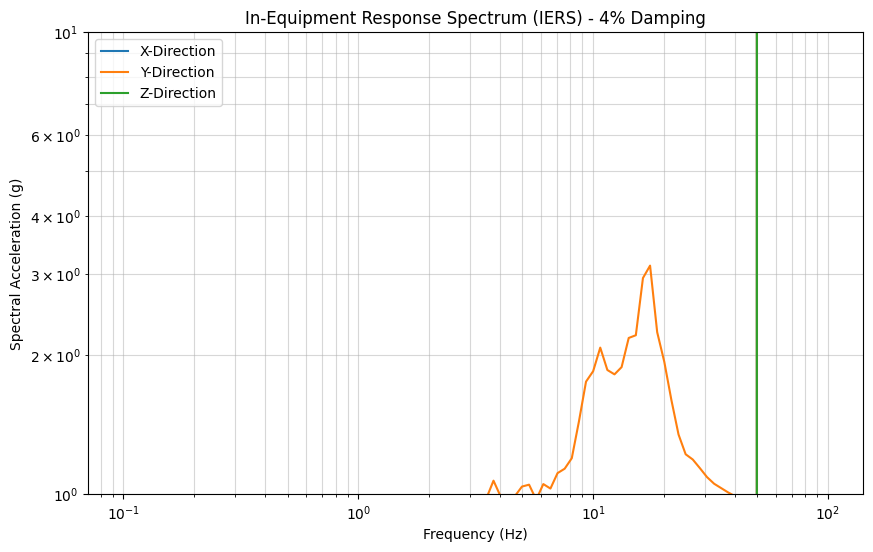

IERS calculation completed and saved.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 파일 경로 설정 (본인의 드라이브 경로에 맞게 수정하세요)
file_path = '/content/drive/MyDrive/FRS_Analysis/damper_accel.csv'

def calculate_response_spectrum(time, accel, damping=0.04, freq_min=0.1, freq_max=100, num_freqs=100):
    """
    Newmark-beta법을 이용한 응답 스펙트럼 계산 (Linear Acceleration Method)
    """
    dt = time[1] - time[0]
    frequencies = np.logspace(np.log10(freq_min), np.log10(freq_max), num_freqs)
    spectral_accel = []

    # Newmark-beta coefficients (gamma=1/2, beta=1/6 for linear acceleration)
    gamma = 0.5
    beta = 1/6

    for f in frequencies:
        omega = 2 * np.pi * f
        k = omega**2
        m = 1.0
        c = 2 * damping * omega * m

        u = 0.0
        v = 0.0
        # 초기 가속도 (f=ma -> a = (-m*ag - c*v - k*u)/m)
        a = -accel[0] - (c*v + k*u)/m

        max_abs_accel = 0

        # Time integration
        for i in range(len(accel)-1):
            p_diff = -(accel[i+1] - accel[i])

            # Effective stiffness
            k_hat = k + (gamma/(beta*dt))*c + (1/(beta*dt**2))*m
            # Effective load
            p_hat_diff = p_diff + ( (1/(2*beta))*m + dt*(1 - gamma/(2*beta))*c )*a + \
                         ( (1/(beta*dt))*m + (gamma/beta)*c )*v

            du = p_hat_diff / k_hat
            dv = (gamma/(beta*dt))*du - (gamma/beta)*v + dt*(1 - gamma/(2*beta))*a
            da = (1/(beta*dt**2))*du - (1/(beta*dt))*v - (1/(2*beta))*a

            u += du
            v += dv
            a += da

            # Total acceleration = Relative + Ground
            total_accel = a + accel[i+1]
            if abs(total_accel) > max_abs_accel:
                max_abs_accel = abs(total_accel)

        spectral_accel.append(max_abs_accel)

    return frequencies, np.array(spectral_accel)

# 3. 데이터 로드
df = pd.read_csv(file_path)

# 단위 변환 (mm/s2 -> g)
g = 9806.65
time = df['Time'].values
acc_x = df['Acc_X'].values / g
acc_y = df['Acc_Y'].values / g
acc_z = df['Acc_Z'].values / g

# 4. 스펙트럼 계산 (4% 감쇠)
print("Calculating IERS for X, Y, Z directions...")
freqs, spec_x = calculate_response_spectrum(time, acc_x, damping=0.04)
_, spec_y = calculate_response_spectrum(time, acc_y, damping=0.04)
_, spec_z = calculate_response_spectrum(time, acc_z, damping=0.04)

# 5. 결과 시각화
plt.figure(figsize=(10, 6))
plt.loglog(freqs, spec_x, label='X-Direction')
plt.loglog(freqs, spec_y, label='Y-Direction')
plt.loglog(freqs, spec_z, label='Z-Direction')

plt.title('In-Equipment Response Spectrum (IERS) - 4% Damping')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Acceleration (g)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

# 6. 결과 저장
result_df = pd.DataFrame({
    'Frequency_Hz': freqs,
    'IERS_X_g': spec_x,
    'IERS_Y_g': spec_y,
    'IERS_Z_g': spec_z
})
result_df.to_csv('/content/drive/MyDrive/FRS_Analysis/IERS_Result.csv', index=False)
print("IERS calculation completed and saved.")